# ✅ 회귀(Regression) 문제 템플릿

## 이 파일을 쓰는 상황
```
정답(Target)이 연속된 숫자 → 예) 423초, 15만원, 자전거 37대
평가지표가 RMSE, MAE, RMSLE
```

## ★ 표시된 곳만 실제 문제에 맞게 바꾸면 됩니다!

## 전체 흐름
```
[Step1] 도구 꺼내기 (라이브러리 불러오기)
[Step2] 데이터 보기 (EDA)
[Step3] 데이터 손질 (전처리)
[Step4] AI 모델 학습 + 평가
[Step5] 테스트 데이터 예측
[Step6] 제출 파일 만들기
```

---
## [Step1] 도구 꺼내기

```
요리하기 전에 냄비, 칼, 도마를 꺼내는 것처럼
코딩하기 전에 필요한 도구(라이브러리)를 먼저 불러옵니다.
```

In [1]:
# 기본 도구 (데이터 다루기)
import numpy as np
import pandas as pd

# 그래프 그리기
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 끄기

In [2]:
# ★ 회귀 모델들 (이 중에서 가장 좋은 것을 골라 씁니다)
from sklearn.linear_model import LinearRegression        # 선형 회귀
from sklearn.tree import DecisionTreeRegressor           # 결정 트리
from sklearn.ensemble import RandomForestRegressor       # 랜덤 포레스트
from sklearn.ensemble import ExtraTreesRegressor         # 엑스트라 트리
from xgboost import XGBRegressor                         # XGBoost
from lightgbm import LGBMRegressor                       # LightGBM

# 데이터 나누기 / 평가 / 튜닝 도구
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [9]:
train = pd.read_csv('./data/train.csv')  # 정답이 있는 학습용 데이터
print("원본 train 크기:", train.shape)
print(train.isnull().sum())

test  = pd.read_csv('./data/test.csv')   # 정답 없는 예측용 데이터
print("원본 train 크기:", test.shape)
print(test.isnull().sum())

print('train 크기:', train.shape)
print('test  크기:', test.shape)
train.head()

원본 train 크기: (32052, 19)
fuel_consumption_rate              22052
eta_variation_hours                22052
traffic_congestion_level           22052
warehouse_inventory_level          22052
loading_unloading_time             22052
handling_equipment_availability    22052
order_fulfillment_status           22052
weather_condition_severity         22052
port_congestion_level              22052
supplier_reliability_score         22052
lead_time_days                     22052
historical_demand                  22052
iot_temperature                    22052
cargo_condition_status             22052
route_risk_level                   22052
customs_clearance_time             22052
driver_behavior_score              22052
fatigue_monitoring_score           22052
shipping_costs                     22052
dtype: int64
원본 train 크기: (2000, 18)
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unl

,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,shipping_costs
0,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,0.359066,4.289160,0.986064,2.128009,100.772854,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,456.503853
1,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,0.230660,7.018373,0.463233,12.608166,5313.738114,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,640.408205
2,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,0.027210,9.605064,0.598561,14.124452,1595.049146,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,155.749314
3,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,0.616619,8.899616,0.742735,3.818972,2530.431941,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,104.317960
4,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,0.952385,0.061760,0.431088,14.001491,2146.190197,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,977.222528


In [10]:
# null 값 확인
print(train.isnull().sum())


fuel_consumption_rate              22052
eta_variation_hours                22052
traffic_congestion_level           22052
warehouse_inventory_level          22052
loading_unloading_time             22052
handling_equipment_availability    22052
order_fulfillment_status           22052
weather_condition_severity         22052
port_congestion_level              22052
supplier_reliability_score         22052
lead_time_days                     22052
historical_demand                  22052
iot_temperature                    22052
cargo_condition_status             22052
route_risk_level                   22052
customs_clearance_time             22052
driver_behavior_score              22052
fatigue_monitoring_score           22052
shipping_costs                     22052
dtype: int64


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32052 entries, 0 to 32051
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   fuel_consumption_rate            10000 non-null  float64
 1   eta_variation_hours              10000 non-null  float64
 2   traffic_congestion_level         10000 non-null  float64
 3   warehouse_inventory_level        10000 non-null  float64
 4   loading_unloading_time           10000 non-null  float64
 5   handling_equipment_availability  10000 non-null  float64
 6   order_fulfillment_status         10000 non-null  float64
 7   weather_condition_severity       10000 non-null  float64
 8   port_congestion_level            10000 non-null  float64
 9   supplier_reliability_score       10000 non-null  float64
 10  lead_time_days                   10000 non-null  float64
 11  historical_demand                10000 non-null  float64
 12  iot_temperature              

In [5]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   fuel_consumption_rate            2000 non-null   float64
 1   eta_variation_hours              2000 non-null   float64
 2   traffic_congestion_level         2000 non-null   float64
 3   warehouse_inventory_level        2000 non-null   float64
 4   loading_unloading_time           2000 non-null   float64
 5   handling_equipment_availability  2000 non-null   float64
 6   order_fulfillment_status         2000 non-null   float64
 7   weather_condition_severity       2000 non-null   float64
 8   port_congestion_level            2000 non-null   float64
 9   supplier_reliability_score       2000 non-null   float64
 10  lead_time_days                   2000 non-null   float64
 11  historical_demand                2000 non-null   float64
 12  iot_temperature                

### 날짜형 변수가 있을 때만! — 월/일/시간/요일로 분리

```
컴퓨터는 '2016-01-18 11:10'이라는 날짜를 이해 못 합니다.
그래서 월(1월), 일(18일), 시간(11시), 요일(월요일=0) 등으로 쪼갭니다.
날짜 컬럼이 없으면 이 셀은 무시하세요!
```

In [ ]:
# ★ 날짜형 컬럼이 있는 경우만 주석 해제해서 사용
# DATE_COL = 'pickup_datetime'  # ★ 날짜 컬럼명 변경

# for df in [train, test]:
#     df[DATE_COL] = pd.to_datetime(df[DATE_COL])   # 날짜형으로 변환
#     df['month'] = df[DATE_COL].dt.month            # 월 (1~12)
#     df['day']   = df[DATE_COL].dt.day              # 일 (1~31)
#     df['hour']  = df[DATE_COL].dt.hour             # 시간 (0~23)
#     df['dow']   = df[DATE_COL].dt.dayofweek        # 요일 (월=0, 일=6)
#     df.drop([DATE_COL], axis=1, inplace=True)      # 원래 날짜 컬럼 삭제

print('날짜 변수 없으면 이 셀 무시!')

### 컬럼 처리 방향 자동 판별

```
이 코드를 실행하면 각 컬럼을 어떻게 처리할지 자동으로 알려줍니다!

❌ 삭제    → drop_cols에 넣기
🔤 OHE    → ohe_cols에 넣기 (글자 → 숫자 번역)
📊 스케일링 → scale_cols에 넣기 (0~1 범위로)
📅 날짜 분리 → 위 셀에서 분리 완료하면 month/day/hour/dow가 🔤로 나옴
⚠️ 결측   → 채워줘야 함
```

In [22]:
import pandas as pd

def analyze_columns(df, target_col, drop_candidates=None):
    if drop_candidates is None:
        drop_candidates = []
    
    analysis_results = []
    
    for col in df.columns:
        if col == target_col:
            analysis_results.append({
                'col_name': col,
                'dtype': str(df[col].dtype),
                'n_unique': df[col].nunique(),
                'n_null': df[col].isnull().sum(),
                'direction': '🎯 TARGET (정답)',
                'is_ohe': False,
                'is_datetime': False,
                'is_drop': False,
                'is_min_max': False  # 쉼표(,) 추가 및 is_min_max 반영
            })
            continue
            
        dtype = str(df[col].dtype)
        n_unique = df[col].nunique()
        n_null = df[col].isnull().sum()
        
        is_ohe = False
        is_datetime = False
        is_drop = False
        is_min_max = False
        
        if col in drop_candidates:
            direction = '❌ 삭제'
            is_drop = True
        elif dtype == 'object':
            if n_unique <= 20:
                direction = '🔤 OHE (글자형 → 숫자로 번역)'
                is_ohe = True
            else:
                direction = '❌ 삭제 검토 (고유값 너무 많음)'
                is_drop = True
        elif 'datetime' in dtype:
            direction = '📅 날짜 분리 후 OHE (월/일/시/요일 추출)'
            is_datetime = True
        elif n_unique <= 10:
            direction = f'🔤 OHE 검토 (숫자지만 {n_unique}가지뿐 → 카테고리 가능)'
            is_ohe = True
        else:
            direction = '📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)'
            is_min_max = True
            
        analysis_results.append({
            'col_name': col,
            'dtype': dtype,
            'n_unique': n_unique,
            'n_null': n_null,
            'direction': direction,
            'is_ohe': is_ohe,
            'is_datetime': is_datetime,
            'is_drop': is_drop,
            'is_min_max': is_min_max  # 반환 딕셔너리에 추가
        })
    
    # 결과를 데이터프레임 변수로 변환
    result_df = pd.DataFrame(analysis_results)
    return result_df

# 실행 및 변수 저장
TARGET = 'shipping_costs'
df_analysis = analyze_columns(train, target_col=TARGET, drop_candidates=['id', 'dropoff_datetime'])

# 결과 확인
display(df_analysis)

,col_name,dtype,n_unique,n_null,direction,is_ohe,is_datetime,is_drop,is_min_max
0,fuel_consumption_rate,float64,9847,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
1,eta_variation_hours,float64,9978,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
2,traffic_congestion_level,float64,10000,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
3,warehouse_inventory_level,float64,9995,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
4,loading_unloading_time,float64,10000,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
5,handling_equipment_availability,float64,9949,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
6,order_fulfillment_status,float64,9997,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
7,weather_condition_severity,float64,9999,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
8,port_congestion_level,float64,9977,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True
9,supplier_reliability_score,float64,9998,22052,📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기),False,False,False,True


---
## [Step2] 데이터 보기 (EDA)

```
요리 전에 재료를 살펴보는 단계입니다.
특히 회귀는 Target(정답)의 분포가 중요합니다.
값이 한쪽으로 너무 치우쳐 있으면 로그 변환이 필요할 수 있습니다.
```

In [23]:
train.describe()

,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,shipping_costs
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,7.977998,2.893533,5.010108e+00,2.998232e+02,2.270805,3.014857e-01,0.602481,4.996589e-01,6.976781,5.000130e-01,5.242187,6017.484850,0.037778,2.969666e-01,6.985193,2.300604,4.993023e-01,0.603880,458.947151
std,4.238661,2.265693,3.527716e+00,3.228993e+02,1.547665,3.262513e-01,0.344995,3.538123e-01,3.237082,3.535265e-01,4.524554,3423.068675,14.188367,3.225977e-01,3.238171,1.553003,3.542907e-01,0.345385,312.365587
min,5.000000,-1.999887,1.090000e-09,8.920000e-11,0.500000,1.900000e-14,0.000004,1.380000e-08,0.000008,2.280000e-08,1.000000,100.022288,-10.000000,2.570000e-17,0.000091,0.500000,8.740000e-08,0.000003,100.000000
25%,5.022589,1.214497,1.493287e+00,1.659448e+01,0.755279,1.726825e-02,0.283544,1.430240e-01,4.513461,1.443718e-01,1.254008,2826.230945,-9.932436,1.630307e-02,4.556036,0.785460,1.445349e-01,0.287389,152.816953
50%,5.614689,3.872394,5.041884e+00,1.605201e+02,1.888011,1.542499e-01,0.678472,5.023235e-01,8.364997,5.014461e-01,3.263730,6756.992407,-7.875532,1.534984e-01,8.369528,1.948432,5.065410e-01,0.687910,391.409517
75%,9.519208,4.885298,8.536509e+00,5.417630e+02,3.702242,5.507516e-01,0.937992,8.535947e-01,9.827141,8.524621e-01,8.737689,9392.540250,6.074399,5.405120e-01,9.825008,3.758535,8.504966e-01,0.936770,751.604227
max,19.999875,5.000000,9.999999e+00,9.999950e+02,4.999981,9.999995e-01,1.000000,9.999999e-01,10.000000,1.000000e+00,14.999995,9999.999986,39.999886,9.999796e-01,10.000000,4.999999,1.000000e+00,1.000000,999.998823


### Target 분포 확인 — 로그 변환이 필요한지 보기

```
왼쪽(원본)이 한쪽으로 치우쳐 있고
오른쪽(로그변환)이 더 종 모양에 가까우면 → 로그 변환 하세요!

특히 평가지표가 RMSLE이면 반드시 로그 변환!
```

In [24]:
target_col = list(set(train.columns) - set(test.columns))
print("🎯 Target 컬럼:", target_col)

🎯 Target 컬럼: ['shipping_costs']


['shipping_costs']


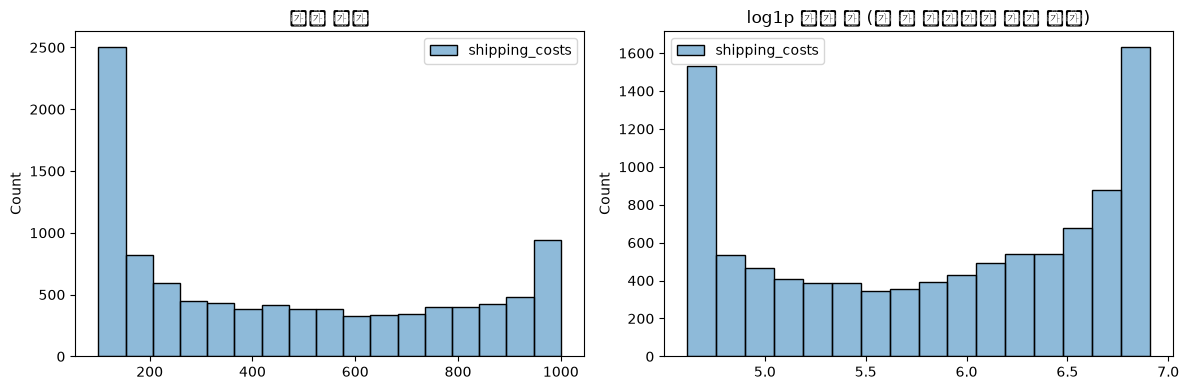

In [25]:
TARGET = list(set(train.columns) - set(test.columns))  # ★ 정답 컬럼명 변경
print(TARGET)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train[TARGET],           ax=axes[0]).set_title('원본 분포')
sns.histplot(np.log1p(train[TARGET]), ax=axes[1]).set_title('log1p 변환 후 (더 종 모양이면 변환 사용)')
plt.tight_layout()
plt.show()

### 양적변수 분포 확인

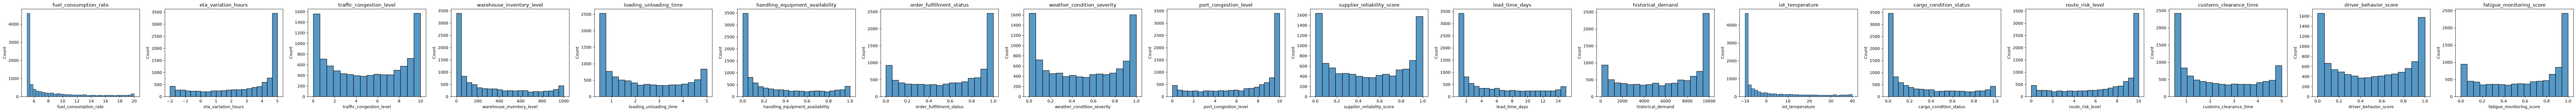

In [26]:
# ★ 📊 표시된 컬럼들로 변경
num_cols = df_analysis[df_analysis['is_min_max']]['col_name'].tolist()

fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for i, col in enumerate(num_cols):
    sns.histplot(train[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 질적변수 분포 확인

In [ ]:
# ★ 🔤 표시된 컬럼들로 변경
cat_cols = ['vendor_id', 'store_and_fwd_flag']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 4))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=train, ax=axes[i])
plt.tight_layout()
plt.show()

### 추가 변수 생성 — 필요할 때만!

```
위도/경도 좌표가 있으면 '이동 거리'를 직접 계산해서 새 컬럼으로 만들 수 있습니다.
이런 식으로 기존 컬럼을 조합해 새로운 의미 있는 값을 만드는 것을 '파생변수'라고 합니다.
필요 없으면 이 셀 무시!
```

In [ ]:
# 예시: 승차/하차 위경도 → 직선 거리 계산
# for df in [train, test]:
#     dist_lon = df['pickup_longitude'] - df['dropoff_longitude']
#     dist_lat = df['pickup_latitude']  - df['dropoff_latitude']
#     df['distance'] = np.sqrt(dist_lon**2 + dist_lat**2)

print('파생변수 불필요하면 이 셀 무시!')

---
## [Step3] 데이터 손질 (전처리)

### (1) 중복값 제거 — train만!

In [27]:
print('중복 행 수:', train.duplicated().sum())
train.drop_duplicates(inplace=True)

중복 행 수: 22051


### (2) 불필요한 컬럼 삭제

```
analyze_columns()에서 ❌ 표시된 것들을 drop_cols에 넣으세요.
```

In [ ]:
# ★ ❌ 표시된 컬럼들 입력
drop_cols = ['id']  # ★ 변경

train.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols,  axis=1, inplace=True)
print('삭제 후 크기:', train.shape, test.shape)

### (3) 결측치(빈칸) 채우기

```
📊 양적변수(숫자) → 평균값으로 채우기
🔤 질적변수(글자) → 가장 많이 나온 값으로 채우기
⚠️ 항상 train으로 기준값 계산! test는 train 기준값을 그대로 적용!
```

In [28]:
print('=== train 결측치 ==='); print(train.isnull().sum())
print('=== test  결측치 ==='); print(test.isnull().sum())

=== train 결측치 ===
fuel_consumption_rate              1
eta_variation_hours                1
traffic_congestion_level           1
warehouse_inventory_level          1
loading_unloading_time             1
handling_equipment_availability    1
order_fulfillment_status           1
weather_condition_severity         1
port_congestion_level              1
supplier_reliability_score         1
lead_time_days                     1
historical_demand                  1
iot_temperature                    1
cargo_condition_status             1
route_risk_level                   1
customs_clearance_time             1
driver_behavior_score              1
fatigue_monitoring_score           1
shipping_costs                     1
dtype: int64
=== test  결측치 ===
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status  

In [68]:
# 컬럼별로 몇 개씩 남았는지 확인
null_counts = train.isnull().sum()
print(null_counts[null_counts > 0])

# 그 컬럼들의 dtype도 함께 확인
print(train.dtypes[null_counts[null_counts > 0].index])

fuel_consumption_rate              10000
eta_variation_hours                10000
traffic_congestion_level           10000
warehouse_inventory_level          10000
loading_unloading_time             10000
handling_equipment_availability    10000
order_fulfillment_status           10000
weather_condition_severity         10000
port_congestion_level              10000
supplier_reliability_score         10000
lead_time_days                     10000
historical_demand                  10000
iot_temperature                    10000
cargo_condition_status             10000
route_risk_level                   10000
customs_clearance_time             10000
driver_behavior_score              10000
fatigue_monitoring_score           10000
dtype: int64
fuel_consumption_rate              float64
eta_variation_hours                float64
traffic_congestion_level           float64
warehouse_inventory_level          float64
loading_unloading_time             float64
handling_equipment_availability   

In [69]:
for c in num_cols:
    if train[c].isnull().all():
        print(c, "→ 이 컬럼은 train에서 전부 결측!")

fuel_consumption_rate → 이 컬럼은 train에서 전부 결측!
eta_variation_hours → 이 컬럼은 train에서 전부 결측!
traffic_congestion_level → 이 컬럼은 train에서 전부 결측!
warehouse_inventory_level → 이 컬럼은 train에서 전부 결측!
loading_unloading_time → 이 컬럼은 train에서 전부 결측!
handling_equipment_availability → 이 컬럼은 train에서 전부 결측!
order_fulfillment_status → 이 컬럼은 train에서 전부 결측!
weather_condition_severity → 이 컬럼은 train에서 전부 결측!
port_congestion_level → 이 컬럼은 train에서 전부 결측!
supplier_reliability_score → 이 컬럼은 train에서 전부 결측!
lead_time_days → 이 컬럼은 train에서 전부 결측!
historical_demand → 이 컬럼은 train에서 전부 결측!
iot_temperature → 이 컬럼은 train에서 전부 결측!
cargo_condition_status → 이 컬럼은 train에서 전부 결측!
route_risk_level → 이 컬럼은 train에서 전부 결측!
customs_clearance_time → 이 컬럼은 train에서 전부 결측!
driver_behavior_score → 이 컬럼은 train에서 전부 결측!
fatigue_monitoring_score → 이 컬럼은 train에서 전부 결측!


In [70]:
import numpy as np

TARGET = 'shipping_costs'

train = train.dropna(subset=[TARGET]).reset_index(drop=True).copy()
print("정리 후 train 크기:", train.shape)

# 1) 결측치 있는 컬럼과 dtype 먼저 점검
null_counts = train.isnull().sum()
print(null_counts[null_counts > 0])
print(train.dtypes[null_counts[null_counts > 0].index])

# 2) 숫자형: np.number로 더 넓게 잡기
num_cols = train.select_dtypes(include=np.number).columns.drop(TARGET, errors='ignore')

for c in num_cols:
    col_mean = train[c].mean()
    if pd.isna(col_mean):          # 전부 NaN인 컬럼 방어
        col_mean = 0
    train[c] = train[c].fillna(col_mean)
    if c in test.columns:
        test[c] = test[c].fillna(col_mean)

# 3) 범주형(object/category)도 함께 처리
cat_cols = train.select_dtypes(include=['object', 'category']).columns.drop(TARGET, errors='ignore')

for c in cat_cols:
    mode_series = train[c].mode(dropna=True)
    fill_val = mode_series[0] if len(mode_series) > 0 else 'Unknown'
    train[c] = train[c].fillna(fill_val)
    if c in test.columns:
        test[c] = test[c].fillna(fill_val)

print("train 결측치 총합:", train.isnull().sum().sum())
print("test  결측치 총합:", test.isnull().sum().sum())


정리 후 train 크기: (10000, 19)
fuel_consumption_rate              10000
eta_variation_hours                10000
traffic_congestion_level           10000
warehouse_inventory_level          10000
loading_unloading_time             10000
handling_equipment_availability    10000
order_fulfillment_status           10000
weather_condition_severity         10000
port_congestion_level              10000
supplier_reliability_score         10000
lead_time_days                     10000
historical_demand                  10000
iot_temperature                    10000
cargo_condition_status             10000
route_risk_level                   10000
customs_clearance_time             10000
driver_behavior_score              10000
fatigue_monitoring_score           10000
dtype: int64
fuel_consumption_rate              float64
eta_variation_hours                float64
traffic_congestion_level           float64
warehouse_inventory_level          float64
loading_unloading_time             float64
handlin

In [66]:
# 1. TARGET 변수를 확실한 문자열로 지정
TARGET = 'shipping_costs'

# 2. 정답(TARGET)이 없는 빈 행들을 완벽하게 삭제 후 인덱스 재설정
train = train.dropna(subset=[TARGET]).reset_index(drop=True)

print("정리 후 train 크기:", train.shape) # (10000, 19)가 나와야 정상!

정리 후 train 크기: (10000, 19)


In [67]:
# TARGET을 제외한 수치형 컬럼 추출
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.drop(TARGET, errors='ignore')

# 평균값 대체
for c in num_cols:
    col_mean = train[c].mean()
    train[c] = train[c].fillna(col_mean)
    test[c] = test[c].fillna(col_mean)

# 결과 확인
print("train 결측치 총합:", train.isnull().sum().sum())
print("test  결측치 총합:", test.isnull().sum().sum())

train 결측치 총합: 180000
test  결측치 총합: 0


In [31]:
# ★ 결측치 있는 컬럼에 맞게 수정
num_cols = df_analysis[df_analysis['is_min_max']]['col_name'].tolist()
print(num_cols)
# 📊 양적변수 결측 → 평균으로 채우기
for c in num_cols:
    col_mean = train[c].mean()
    train[c].fillna(col_mean, inplace=True)
    test[c].fillna(col_mean, inplace=True)

# 🔤 질적변수 결측 → 최빈값으로 채우기
# col_mode = train['컬럼명'].mode()[0]
# train['컬럼명'].fillna(col_mode, inplace=True)
# test['컬럼명'].fillna(col_mode, inplace=True)

print('결측치 없으면 이 셀 무시!')

['fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score']
결측치 없으면 이 셀 무시!


In [60]:
train = train.dropna(subset=[TARGET])

In [65]:
# TARGET을 제외한 모든 수치형 컬럼 추출
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.drop(TARGET, errors='ignore')

# 평균값으로 결측치 처리
for c in num_cols:
    col_mean = train[c].mean()
    train[c] = train[c].fillna(col_mean)
    test[c] = test[c].fillna(col_mean)

print("train 결측치 총합:", train.isnull().sum().sum())
print("test  결측치 총합:", test.isnull().sum().sum())

train 결측치 총합: 180000
test  결측치 총합: 0


In [63]:
# 📊 수치형 변수 결측치 평균값으로 채우기
num_cols = df_analysis[df_analysis['is_min_max']]['col_name'].tolist()

for c in num_cols:
    col_mean = train[c].mean()
    train[c] = train[c].fillna(col_mean)
    test[c] = test[c].fillna(col_mean)

# 결측치가 잘 채워졌는지 확인 (0이 나와야 정상)
print("train 결측치 총합:", train.isnull().sum().sum())
print("test  결측치 총합:", test.isnull().sum().sum())

train 결측치 총합: 180000
test  결측치 총합: 0


### (4) 아웃라이어(이상치) 제거 — train & 양적변수만!

```
회귀 문제는 Target(정답)도 아웃라이어 제거 대상입니다!
(분류와 다른 점!)

왜? 정답이 '432초'인데 딱 하나가 '86000초'이면
    AI가 "가끔 86000초도 나올 수 있구나"라고 잘못 배웁니다.

IQR 방법 = 자동으로 이상한 범위 계산해서 제거
```

In [50]:
TARGET = 'shipping_costs'

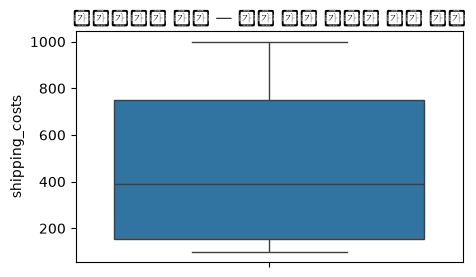

In [51]:
# TARGET = 'trip_duration'  # ★ 정답 컬럼명 변경

# boxplot으로 아웃라이어 확인 (박스 밖으로 튀는 점 = 아웃라이어)
plt.figure(figsize=(5, 3))
sns.boxplot(y=TARGET, data=train)
plt.title('아웃라이어 확인 — 점이 많이 보이면 제거 필요')
plt.show()

In [39]:
# IQR 방법으로 아웃라이어 제거 (★ Target 컬럼명 변경)
# TARGET = 'trip_duration'

Q1  = train[TARGET].quantile(0.25)  # 하위 25% 값
Q3  = train[TARGET].quantile(0.75)  # 상위 25% 값
IQR = Q3 - Q1                       # 범위
MIN = Q1 - 1.5 * IQR                # 이 값보다 작으면 이상치
MAX = Q3 + 1.5 * IQR                # 이 값보다 크면 이상치

train = train[(train[TARGET] >= MIN) & (train[TARGET] <= MAX)]
print(f'아웃라이어 제거 후 train: {train.shape}  (남은 데이터 수)')

KeyError: 'shipping_cost'

In [ ]:
# Feature 컬럼에도 필요하면 동일하게 적용
# col = '컬럼명'  # ★ 변경
# Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
# IQR = Q3 - Q1
# train = train[(train[col] >= Q1-1.5*IQR) & (train[col] <= Q3+1.5*IQR)]

### (5) Feature(입력) / Target(정답) 분리

In [71]:
# TARGET = 'trip_duration'  # ★ 정답 컬럼명 변경

Xtrain = train.drop([TARGET], axis=1)
ytrain  = train[TARGET]
Xtest  = test.copy()

print('Xtrain:', Xtrain.shape, '  ytrain:', ytrain.shape, '  Xtest:', Xtest.shape)

Xtrain: (10000, 18)   ytrain: (10000,)   Xtest: (2000, 18)


### (6) OHE — 글자를 숫자로 번역

```
analyze_columns()에서 🔤 표시된 컬럼들을 ohe_cols에 넣으세요.
```

In [72]:
# ★ 🔤 표시된 컬럼들 입력 (Target 제외!)
# ohe_cols = ['vendor_id', 'store_and_fwd_flag']  # ★ 변경
ohe_cols = []
Xtrain_ohe = pd.get_dummies(Xtrain, columns=ohe_cols)
Xtest_ohe  = pd.get_dummies(Xtest,  columns=ohe_cols)

print('OHE 후 컬럼 수 - Xtrain:', Xtrain_ohe.shape[1], '  Xtest:', Xtest_ohe.shape[1])

OHE 후 컬럼 수 - Xtrain: 18   Xtest: 18


### (7) 스케일링 — 숫자 단위 통일

```
⚠️ fit_transform(train) 기준 계산 + 변환
   transform(test)       변환만! (계산 다시 하면 안 됨)
```

In [73]:
minmax_scaler = MinMaxScaler()

# OHE 후 전체 컬럼 스케일링
Xtrain_ohe_scaled = pd.DataFrame(
    data=minmax_scaler.fit_transform(Xtrain_ohe),  # train: 기준 계산 + 변환
    columns=Xtrain_ohe.columns,
    index=Xtrain_ohe.index
)
Xtest_ohe_scaled = pd.DataFrame(
    data=minmax_scaler.transform(Xtest_ohe),        # test: 변환만!
    columns=Xtest_ohe.columns,
    index=Xtest_ohe.index
)
print('스케일링 완료! 크기:', Xtrain_ohe_scaled.shape)

스케일링 완료! 크기: (10000, 18)


### (8) Target 로그 변환 — 분포가 치우쳐 있을 때!

```
대부분 값이 400~1000초인데 극소수가 80000초처럼 튀는 경우,
AI가 그 튀는 값에 과도하게 집중해버립니다.

로그 변환 = 큰 숫자 차이를 줄여줌
  1000 → 6.9,  10000 → 9.2,  100000 → 11.5  (차이가 훨씬 작아짐!)

Step2에서 오른쪽 그래프가 더 종 모양이면 → 로그 변환 사용!
평가지표가 RMSLE이면 → 무조건 로그 변환!
```

In [74]:
# log1p = log(값+1) 변환  (0이 있어도 처리 가능)
ytrain_log = np.log1p(ytrain)

print('변환 전 최댓값:', ytrain.max())
print('변환 후 최댓값:', ytrain_log.max(), '  (훨씬 작아짐!)')

# ★ 로그 변환 안 할 때는: ytrain_log = ytrain  (그냥 같은 값 사용)

변환 전 최댓값: 999.9988231
변환 후 최댓값: 6.908753603590253   (훨씬 작아짐!)


---
## [Step4] AI 모델 학습 + 평가

### (1) 회귀 평가지표 함수 만들기

```
회귀 평가지표는 종류가 여러 가지입니다.
문제에서 요구하는 평가지표를 사용하세요.

RMSLE: 평가지표가 RMSLE이면 이것 사용
RMSE:  평가지표가 RMSE이면 이것 사용
```

In [75]:
# ★ RMSLE (Root Mean Squared Log Error)
# 로그 변환한 실제값과 예측값의 차이를 구하는 함수
def rmsle(log1p_actual, log1p_pred):
    squared_error = (log1p_actual - log1p_pred) ** 2
    return np.sqrt(np.mean(squared_error))

# ★ RMSE (Root Mean Squared Error)
def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

# MAE, R²는 sklearn 함수 그대로 사용:
# mean_absolute_error(y_val, pred)
# r2_score(y_val, pred)

### (2) train / val 분리

In [76]:
# ★ 로그 변환했으면 ytrain_log 사용, 안 했으면 ytrain 사용
X_train, X_val, y_train, y_val = train_test_split(
    Xtrain_ohe_scaled, ytrain_log,   # ★ 로그 변환 안 했으면 ytrain_log → ytrain
    test_size=0.2,
    random_state=0
)
print('학습용:', X_train.shape, '  검증용:', X_val.shape)

학습용: (8000, 18)   검증용: (2000, 18)


### (3) 여러 모델 학습 → 가장 좋은 모델 찾기

```
★ 회귀: 평가지표(RMSLE, RMSE 등)가 낮을수록 좋음!
         0에 가까울수록 예측이 정확

실행 후 가장 마지막에 출력된 '최종 선택 모델'이 최선입니다.
그 모델의 파라미터가 자동으로 출력됩니다 → GridSearchCV에 복붙!
```

In [77]:
models = {
    'LinearRegression':      LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(n_jobs=-1),
    'ExtraTreesRegressor':   ExtraTreesRegressor(n_jobs=-1),
    'XGBRegressor':          XGBRegressor(verbose=-1, n_jobs=-1),
    'LGBMRegressor':         LGBMRegressor(verbose=-1, n_jobs=-1)
}

selected_estimator = None
min_score = float('inf')  # 회귀: 낮을수록 좋으니 무한대로 시작

for name, estimator in models.items():
    estimator.fit(X_train, y_train)       # 학습
    pred  = estimator.predict(X_val)      # 예측
    score = rmsle(y_val, pred)            # ★ 평가지표 함수 (문제에 맞게 변경)
    print(f'[{name}] rmsle: {round(score, 4)}')

    if score < min_score:                 # 더 낮으면 교체
        selected_estimator = estimator
        min_score = score
        print(f'  ★ 현재 최선!')
    print()

print('=' * 50)
print('최종 선택 모델:', type(selected_estimator).__name__)

# 선택된 모델의 권장 파라미터 자동 출력
PARAM_GUIDE = {
    'LGBMRegressor':         {'learning_rate': [0.05, 0.1, 0.14], 'n_estimators': [100, 200, 300]},
    'XGBRegressor':          {'learning_rate': [0.05, 0.1, 0.2],  'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7]},
    'RandomForestRegressor': {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10]},
    'ExtraTreesRegressor':   {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10]},
    'DecisionTreeRegressor': {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]},
}
model_name = type(selected_estimator).__name__
if model_name in PARAM_GUIDE:
    print(f'\n[{model_name}] 아래 파라미터를 GridSearchCV에 복붙하세요:')
    print('parameters = {')
    for k, v in PARAM_GUIDE[model_name].items():
        print(f"    '{k}': {v},")
    print('}')

[LinearRegression] rmsle: 0.8113
  ★ 현재 최선!

[DecisionTreeRegressor] rmsle: 0.8113

[RandomForestRegressor] rmsle: 0.8112
  ★ 현재 최선!

[ExtraTreesRegressor] rmsle: 0.8113

[XGBRegressor] rmsle: 0.8113

[LGBMRegressor] rmsle: 0.8113

최종 선택 모델: RandomForestRegressor

[RandomForestRegressor] 아래 파라미터를 GridSearchCV에 복붙하세요:
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
}


### (4) 하이퍼파라미터 튜닝 (GridSearchCV)

```
위에서 출력된 파라미터를 아래 parameters 딕셔너리에 복붙하세요!

★ 회귀: make_scorer 사용 (분류와 다른 점!)
   greater_is_better=False → 낮을수록 좋은 지표임을 알려줌
```

In [78]:
# 먼저 기본 파라미터로 CV 성능 확인
grid_reg = GridSearchCV(
    selected_estimator, param_grid={}, cv=5,
    scoring=make_scorer(rmsle, greater_is_better=False)
)
grid_reg.fit(Xtrain_ohe_scaled, ytrain_log)
print('기본 파라미터 CV 성능 (RMSLE):', abs(round(grid_reg.best_score_, 4)))

기본 파라미터 CV 성능 (RMSLE): 0.807


In [79]:
# ★ 위 모델 for문 결과에서 출력된 파라미터를 여기에 복붙!
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
}

grid_reg = GridSearchCV(
    selected_estimator,
    param_grid=parameters,
    cv=5,
    scoring=make_scorer(rmsle, greater_is_better=False)  # ★ 회귀
)
grid_reg.fit(Xtrain_ohe_scaled, ytrain_log)

print('최적 파라미터:', grid_reg.best_params_)
print('최적 CV 성능 (RMSLE):', abs(round(grid_reg.best_score_, 4)))

최적 파라미터: {'max_depth': 10, 'n_estimators': 100}
최적 CV 성능 (RMSLE): 0.8069


---
## [Step5] 테스트 데이터 예측

In [80]:
# 튜닝된 최선 모델로 test 예측
pred_test = grid_reg.best_estimator_.predict(Xtest_ohe_scaled)

# 튜닝 생략한 경우: pred_test = selected_estimator.predict(Xtest_ohe_scaled)

print('예측값 샘플 (로그 상태):', pred_test[:5])

예측값 샘플 (로그 상태): [5.84219588 5.84219588 5.84219588 5.84219588 5.84219588]


In [81]:
# ★ 로그 변환 했다면 → 반드시 역변환! (안 하면 제출값이 이상함)
# expm1 = exp(값) - 1  (log1p의 반대)
pred_test = np.expm1(pred_test)

# ★ 로그 변환 안 했다면 이 셀 건너뛰기!

print('역변환 후 예측값 샘플 (원래 단위):', pred_test[:5])

역변환 후 예측값 샘플 (원래 단위): [343.53506948 343.53506948 343.53506948 343.53506948 343.53506948]


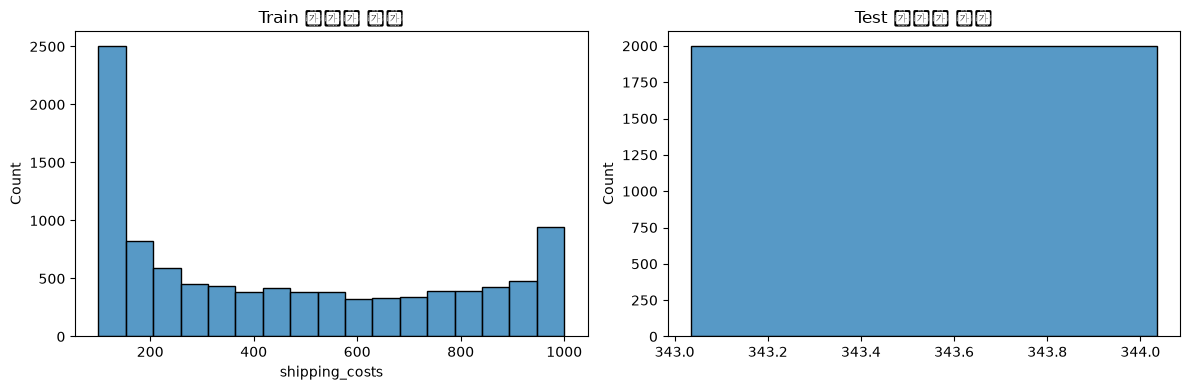

In [82]:
# train 실제값 vs test 예측값 분포 비교 (비슷해야 정상!)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(x=ytrain,    ax=axes[0]).set_title('Train 실제값 분포')
sns.histplot(x=pred_test, ax=axes[1]).set_title('Test 예측값 분포')
plt.tight_layout()
plt.show()

---
## [Step6] 제출 파일 만들기

In [88]:
submission = pd.read_csv('./data/sample-submission.csv')
submission.head()
submission.value_counts()

shipping_costs
0                 2000
Name: count, dtype: int64

In [89]:
# ★ 제출 파일의 target 컬럼명으로 변경

submission[TARGET] = pred_test
submission.head(10)

,shipping_costs
0,343.535069
1,343.535069
2,343.535069
3,343.535069
4,343.535069
5,343.535069
6,343.535069
7,343.535069
8,343.535069
9,343.535069


In [90]:
submission.to_csv('./data/MySubmission.csv', index=False)
print('✅ 제출 파일 저장 완료! → data/MySubmission.csv')

✅ 제출 파일 저장 완료! → data/MySubmission.csv


In [91]:
train.value_counts()

fuel_consumption_rate  eta_variation_hours  traffic_congestion_level  warehouse_inventory_level  loading_unloading_time  handling_equipment_availability  order_fulfillment_status  weather_condition_severity  port_congestion_level  supplier_reliability_score  lead_time_days  historical_demand  iot_temperature  cargo_condition_status  route_risk_level  customs_clearance_time  driver_behavior_score  fatigue_monitoring_score  shipping_costs
0.0                    0.0                  0.0                       0.0                        0.0                     0.0                              0.0                       0.0                         0.0                    0.0                         0.0             0.0                0.0              0.0                     0.0               0.0                     0.0                    0.0                       100.000000        2
                                                                                                                 